In [1]:
import numpy as np
import gudhi as gd
from sklearn.utils import resample
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons

# **Función para Calcular el Umbral Bootstrap C_alpha**

In [2]:
def umbral_bootstrap(X, alpha=0.05, n_iteraciones=500):
    #Calcular diagrama de dimensión cero
    rips_complex = gd.RipsComplex(points=X)
    simplex_tree = rips_complex.create_simplex_tree(max_dimension=1)
    persistencia = simplex_tree.persistence()
    diag_orig = simplex_tree.persistence_intervals_in_dimension(0)

    # Filtrar el punto que vive para siempre para el cálculo de distancias
    diag_orig = diag_orig[np.isfinite(diag_orig[:, 1])]

    bottleneck_dist = []
    n_samples=int(len(X)*0.8)
    
    # Bucle de Bootstrap
    for i in range(n_iteraciones):
        # Submuestreo
        X_sub = resample(X, n_samples=n_samples, replace=True)

        rips_sub = gd.RipsComplex(points=X_sub)
        st_sub = rips_sub.create_simplex_tree(max_dimension=1)
        st_sub.persistence()

        diag_sub = st_sub.persistence_intervals_in_dimension(0)
        diag_sub = diag_sub[np.isfinite(diag_sub[:, 1])]

        #Distancia de Bottleneck
        d = gd.bottleneck_distance(diag_orig, diag_sub)
        bottleneck_dist.append(d)

    # Tomar el percentil (1 - alpha)
    c_alpha = np.percentile(bottleneck_dist, (1 - alpha) * 100)
    return c_alpha, diag_orig

# **Prueba con Diferentes Niveles de Ruido**

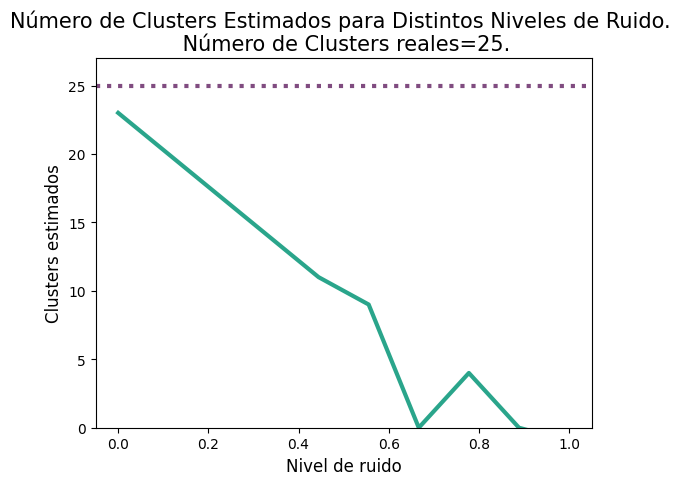

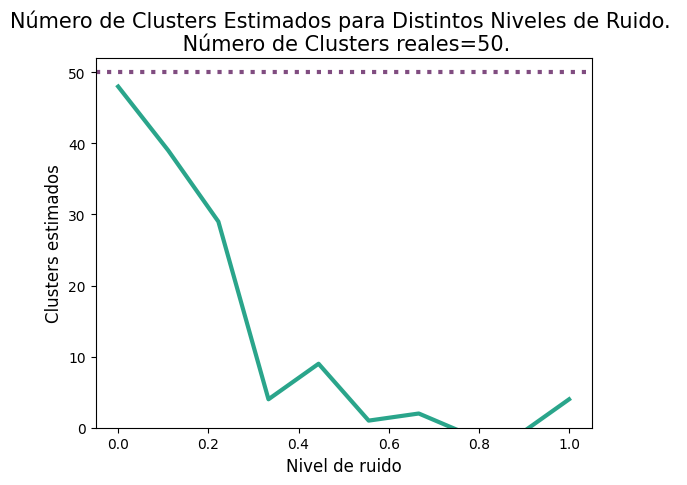

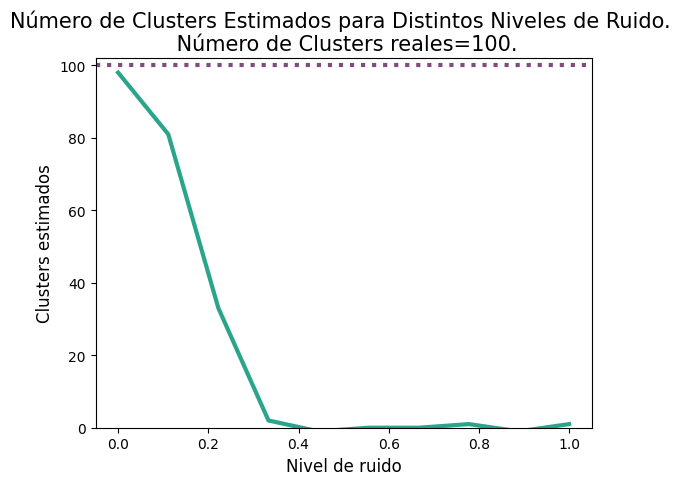

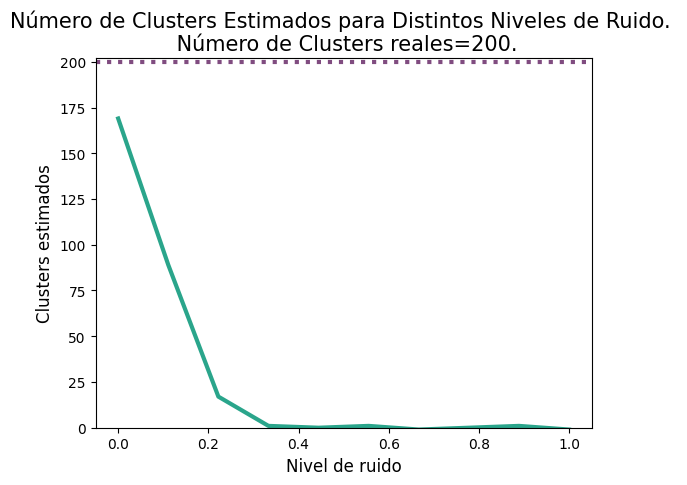

In [3]:
N=10
interval=np.linspace(0,1,N)
n_puntos=1000
n_clusters=[25, 50, 100, 200]

for j in range(len(n_clusters)):
    estimaciones=[]
    for i in range(N):
        Datos,y=make_blobs(n_samples=n_puntos, centers=n_clusters[j], n_features=2, cluster_std=interval[i])
        umbral, diagrama=umbral_bootstrap(Datos)
        puntos_significativos=[x for x in diagrama[:,1] if x>2*umbral]
        estimaciones.append(len(puntos_significativos)-1)
    plt.figure()
    plt.plot(interval, estimaciones, color='#2AA58B', linewidth=3)
    plt.axhline(y=n_clusters[j], color='#804C80', linewidth=3, linestyle=':')
    plt.title(f'Número de Clusters Estimados para Distintos Niveles de Ruido. \n Número de Clusters reales={n_clusters[j]}.', fontsize=15)
    plt.ylim(0,n_clusters[j]+2)
    plt.xlabel('Nivel de ruido', fontsize=12)
    plt.ylabel('Clusters estimados', fontsize=12)
    plt.show()